# 📊 Sentiment Analysis of Customer Reviews — End-to-End Notebook
This notebook trains and evaluates **Naïve Bayes, Linear SVM, and KNN** using TF–IDF features, saves the **best model** and evaluation artifacts, and demonstrates **explainability (ELI5)**.

**How to use:** Run cells **top → bottom**. Replace the dataset path in the config cell to use your data.


## 0) (Optional) Install dependencies

In [1]:

# !pip install -q scikit-learn pandas numpy matplotlib joblib nltk eli5
# Optional (transformers baseline):
# !pip install -q transformers torch datasets
%matplotlib inline


## 1) Imports & configuration

In [2]:

from pathlib import Path
import re, string, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# Explainability (optional)
try:
    import eli5
    from eli5.sklearn import explain_prediction_linear_classifier, explain_weights_linear_classifier
    _HAS_ELI5 = True
except Exception:
    _HAS_ELI5 = False

# Optional lemmatization (off by default)
USE_LEMMATIZATION = False
try:
    import nltk
    from nltk.stem import WordNetLemmatizer
    _HAS_NLTK = True
    lemmatizer = WordNetLemmatizer()
except Exception:
    _HAS_NLTK = False
    lemmatizer = None

RANDOM_STATE = 42
TEST_SIZE   = 0.2
N_SPLITS    = 5

# === CHANGE THIS TO YOUR DATA ===
# Must have a text column (text/review/content/sentence/comment) and a label column (label/sentiment/target/class)
DATA_CSV = Path(r"C:\\Users\\Admin\\IMDBDataset.csv")   # e.g. Path(r"C:\\Users\\Admin\\IMDBDataset.csv") on Windows
OUT_DIR  = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
MODEL_DIR= Path("models");  MODEL_DIR.mkdir(exist_ok=True)
print("Using dataset:", DATA_CSV.resolve())


Using dataset: C:\Users\Admin\IMDBDataset.csv


## 2) (Optional) NLTK downloads if you enable lemmatization

In [3]:

if USE_LEMMATIZATION and _HAS_NLTK:
    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet', quiet=True)
    try:
        nltk.data.find('corpora/omw-1.4')
    except LookupError:
        nltk.download('omw-1.4', quiet=True)


## 3) Preprocessing helpers

In [4]:

import string, re
_PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def simple_clean(text: str) -> str:
    if not isinstance(text, str): return ""
    t = text.lower()
    t = t.translate(_PUNCT_TABLE)
    t = re.sub(r"\s+"," ", t).strip()
    return t

def lemmatize_text(text: str) -> str:
    if not USE_LEMMATIZATION or not _HAS_NLTK or lemmatizer is None:
        return text
    return " ".join(lemmatizer.lemmatize(tok) for tok in text.split())

def preprocess_series(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str).map(simple_clean)
    if USE_LEMMATIZATION and _HAS_NLTK:
        s = s.map(lemmatize_text)
    return s


## 4) Load dataset (auto-detect columns)
If file missing, create a small sample to let you test the flow.

In [5]:

if not DATA_CSV.exists():
    DATA_CSV.parent.mkdir(parents=True, exist_ok=True)
    sample = pd.DataFrame({
        "text":[
            "I absolutely loved this product! It exceeded my expectations.",
            "This is the worst experience I have ever had.",
            "Pretty decent, not too bad but not great either.",
            "Amazing quality and fantastic customer service!",
            "I would not recommend this at all, total waste of money.",
            "Great value for the price, I am very satisfied.",
            "Terrible, it broke after one use.",
            "It was okay, nothing special.",
            "Superb performance, I will buy again!",
            "Disappointed with the quality, expected much better."
        ],
        "label":["positive","negative","positive","positive","negative","positive","negative","positive","positive","negative"]
    })
    sample.to_csv(DATA_CSV, index=False)
    print("Created sample dataset:", DATA_CSV.resolve())

df_raw = pd.read_csv(DATA_CSV)
text_col = next((c for c in df_raw.columns if c.lower() in {"text","review","content","sentence","comment"}), None)
label_col= next((c for c in df_raw.columns if c.lower() in {"label","sentiment","target","polarity","class"}), None)
if text_col is None or label_col is None:
    raise ValueError("CSV must include text/review/content/sentence/comment and label/sentiment/target/class columns.")
df = df_raw[[text_col, label_col]].rename(columns={text_col:"text", label_col:"label"})
display(df.head()); print("Classes:", df['label'].unique())


,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Classes: ['positive' 'negative']


## 5) Split, vectorizer, models, and grids

In [6]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

X = preprocess_series(df["text"])
y = df["label"].astype(str)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

vectorizer = TfidfVectorizer(
    min_df=2, max_df=0.95, ngram_range=(1,2), sublinear_tf=True, strip_accents="unicode"
)

models = {
    "NaiveBayes": MultinomialNB(),
    "LinearSVM": LinearSVC(),
    "KNN": KNeighborsClassifier(),
}

param_grids = {
    "NaiveBayes": {"clf__alpha": [0.1, 0.3, 0.7, 1.0]},
    "LinearSVM": {"clf__C": [0.25, 0.5, 1.0, 2.0], "clf__loss": ["hinge","squared_hinge"]},
    "KNN": {"clf__n_neighbors": [5, 9, 11], "clf__weights": ["uniform","distance"]},
}


## 6) Train, evaluate, confusion matrices


[Training] NaiveBayes
Fitting 5 folds for each of 4 candidates, totalling 20 fits
              precision    recall  f1-score   support

    negative     0.8938    0.9004    0.8971      5000
    positive     0.8997    0.8930    0.8963      5000

    accuracy                         0.8967     10000
   macro avg     0.8967    0.8967    0.8967     10000
weighted avg     0.8967    0.8967    0.8967     10000



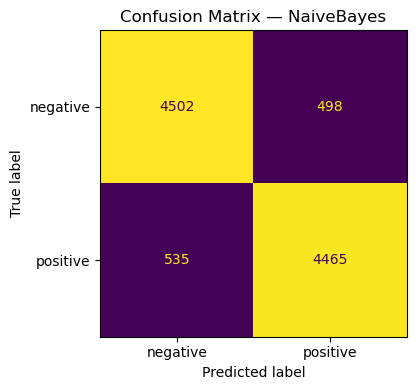


[Training] LinearSVM
Fitting 5 folds for each of 8 candidates, totalling 40 fits
              precision    recall  f1-score   support

    negative     0.9281    0.9162    0.9221      5000
    positive     0.9173    0.9290    0.9231      5000

    accuracy                         0.9226     10000
   macro avg     0.9227    0.9226    0.9226     10000
weighted avg     0.9227    0.9226    0.9226     10000



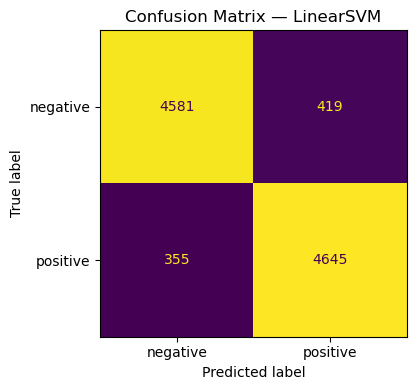


[Training] KNN
Fitting 5 folds for each of 6 candidates, totalling 30 fits


D:\Users\Admin\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan 0.84213644]
  warnings.warn(


              precision    recall  f1-score   support

    negative     0.8797    0.8102    0.8435      5000
    positive     0.8241    0.8892    0.8554      5000

    accuracy                         0.8497     10000
   macro avg     0.8519    0.8497    0.8495     10000
weighted avg     0.8519    0.8497    0.8495     10000



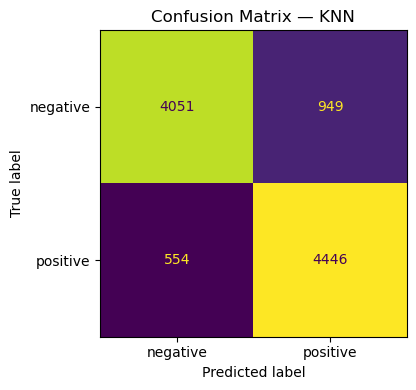


Best model: LinearSVM F1-macro: 92.26 %


In [7]:

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

results = []
best_f1 = -1.0
best_name, best_estimator = None, None

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
labels_sorted = sorted(y.unique())

for name, model in models.items():
    print(f"\n[Training] {name}")
    pipe = Pipeline([("tfidf", vectorizer), ("clf", model)])
    grid = GridSearchCV(pipe, param_grids.get(name, {}), scoring="f1_macro", cv=cv, n_jobs=-1, refit=True, verbose=2)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    prec= precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted).plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    results.append({"model": name, "best_params": grid.best_params_,
                    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})

    if f1 > best_f1:
        best_f1 = f1; best_name = name; best_estimator = grid.best_estimator_

print("\nBest model:", best_name, "F1-macro:", round(best_f1*100,2), "%")


## 7) Metrics summary + save artifacts

In [ ]:

import json, joblib
metrics_df = pd.DataFrame([
    {"Model": r["model"],
     "Accuracy (%)": round(r["accuracy"]*100,2),
     "Precision (%)": round(r["precision"]*100,2),
     "Recall (%)": round(r["recall"]*100,2),
     "F1-Score (%)": round(r["f1"]*100,2),
     "Best Params": r["best_params"]}
    for r in results
])
display(metrics_df)

metrics_path = OUT_DIR / "metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path.resolve())

assert best_estimator is not None
model_path = MODEL_DIR / f"best_model_{best_name}.joblib"
joblib.dump(best_estimator, model_path)

summary = {"best_model": best_name, "best_f1_macro(%)": round(best_f1*100,2), "model_path": str(model_path)}
with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
summary


## 8) Single prediction + (optional) ELI5 explainability

In [ ]:

def predict_text(pipe: Pipeline, text: str):
    cleaned = simple_clean(text)
    pred = pipe.predict([cleaned])[0]
    conf = None
    try:
        if hasattr(pipe, "decision_function"):
            dfun = pipe.decision_function([cleaned])
            conf = float(1/(1+np.exp(-np.max(dfun)))) if np.ndim(dfun) else float(1/(1+np.exp(-dfun)))
        elif hasattr(pipe, "predict_proba"):
            conf = float(np.max(pipe.predict_proba([cleaned])[0]))
    except Exception:
        pass
    return pred, conf

loaded = joblib.load(model_path)
text_demo = "I absolutely loved the product! Super fast delivery."
pred, conf = predict_text(loaded, text_demo)
print({"text": text_demo, "prediction": pred, "confidence": conf})

# ELI5 explanations (works best for LinearSVM/LogReg)
try:
    import eli5
    vec = loaded.named_steps["tfidf"]
    clf = loaded.named_steps["clf"]
    display(eli5.show_weights(clf, top=20, feature_names=vec.get_feature_names_out().tolist()))
    display(eli5.show_prediction(clf, simple_clean(text_demo), vec=vec, top=15))
except Exception as e:
    print("ELI5 not available:", e)
